<a href="https://colab.research.google.com/github/n247298/TCC/blob/main/TCC_Vibration_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Informações iniciais

Estamos usando o *Vibration dataset of main journal bearings in internal combustion engines under diverse climatic and varying operating conditions* que pode ser encontrado em https://data.mendeley.com/datasets/3fcrrdjjvk/5






In [ ]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [ ]:
# Conexão do colab com o drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
df = pd.read_csv("/content/gdrive/MyDrive/TCC/engine_bearing_csv_dataset.csv")

In [ ]:
cols_to_convert = [
    "Demand_RMS",
    "Control_RMS",
    "Ch1_Ov", "Ch1_IB",
    "Ch2_Ov", "Ch2_IB",
    "Ch3_Ov", "Ch3_IB",
    "Ch4_Ov", "Ch4_IB"
]

for col in cols_to_convert:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .astype(float)
    )

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Label        242 non-null    object 
 1   RPM          242 non-null    int64  
 2   Humidity_%   242 non-null    int64  
 3   Temp_C       242 non-null    int64  
 4   Demand_RMS   242 non-null    float64
 5   Control_RMS  242 non-null    float64
 6   Ch1_Ov       242 non-null    float64
 7   Ch1_IB       242 non-null    float64
 8   Ch2_Ov       242 non-null    float64
 9   Ch2_IB       242 non-null    float64
 10  Ch3_Ov       242 non-null    float64
 11  Ch3_IB       242 non-null    float64
 12  Ch4_Ov       242 non-null    float64
 13  Ch4_IB       242 non-null    float64
dtypes: float64(10), int64(3), object(1)
memory usage: 26.6+ KB


In [ ]:
df.describe()

,RPM,Humidity_%,Temp_C,Demand_RMS,Control_RMS,Ch1_Ov,Ch1_IB,Ch2_Ov,Ch2_IB,Ch3_Ov,Ch3_IB,Ch4_Ov,Ch4_IB
count,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000,242.000000
mean,1500.000000,50.000000,16.673554,0.498450,0.528001,0.556041,0.506748,0.584877,0.545645,1.657081,1.224750,0.000942,0.000802
std,409.938767,40.993877,22.577410,0.024106,0.036025,0.057644,0.041972,0.069074,0.056456,1.633067,0.246355,0.000848,0.000722
min,1000.000000,0.000000,-10.000000,0.125000,0.189500,0.189100,0.188000,0.198200,0.190500,0.887500,0.835400,0.000000,0.000000
25%,1000.000000,0.000000,-10.000000,0.500000,0.513025,0.514825,0.489500,0.548525,0.522950,1.096000,1.069500,0.000000,0.000000
50%,1500.000000,50.000000,15.000000,0.500000,0.519600,0.544300,0.498300,0.567250,0.534850,1.238500,1.217500,0.001671,0.001429
75%,2000.000000,100.000000,45.000000,0.500000,0.536900,0.584500,0.506775,0.610425,0.567650,1.342500,1.302250,0.001707,0.001451
max,2000.000000,100.000000,45.000000,0.500000,0.729500,0.749100,0.686300,0.863100,0.769900,13.860000,2.977000,0.001798,0.001495


In [ ]:
df.head()

,Label,RPM,Humidity_%,Temp_C,Demand_RMS,Control_RMS,Ch1_Ov,Ch1_IB,Ch2_Ov,Ch2_IB,Ch3_Ov,Ch3_IB,Ch4_Ov,Ch4_IB
0,Faulty,1000,0,-10,0.5,0.5198,0.5272,0.5097,0.5574,0.5291,0.9982,0.9944,0.000000,0.000000
1,Faulty,1000,0,-10,0.5,0.4975,0.4876,0.4715,0.5342,0.5215,1.1590,1.1700,0.000000,0.000000
2,Faulty,1000,0,-10,0.5,0.5155,0.5570,0.5084,0.5364,0.5218,1.2280,1.2490,0.001670,0.001421
3,Faulty,1000,0,-10,0.5,0.5178,0.5631,0.5087,0.5441,0.5260,1.2740,1.2690,0.001673,0.001423
4,Faulty,1000,0,-10,0.5,0.5166,0.5640,0.5048,0.5472,0.5275,1.2640,1.2570,0.001667,0.001423


In [ ]:
df["Label"].value_counts()

,count
Label,
Faulty,135
Healthy,107


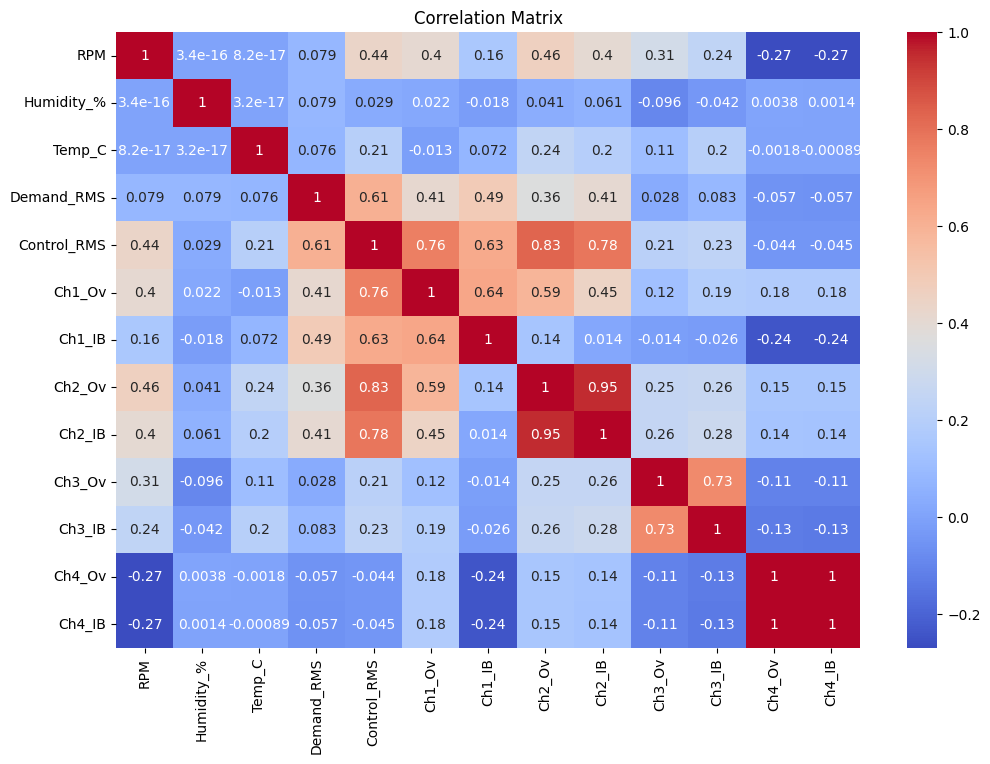

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

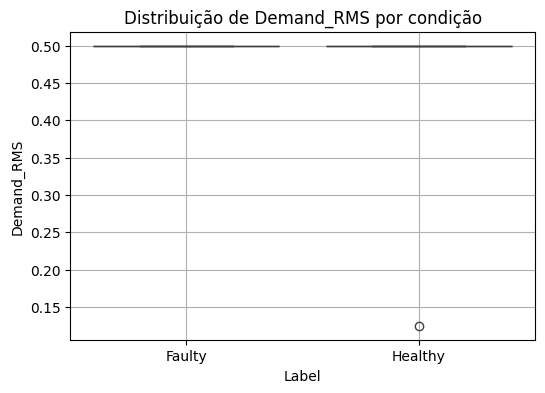

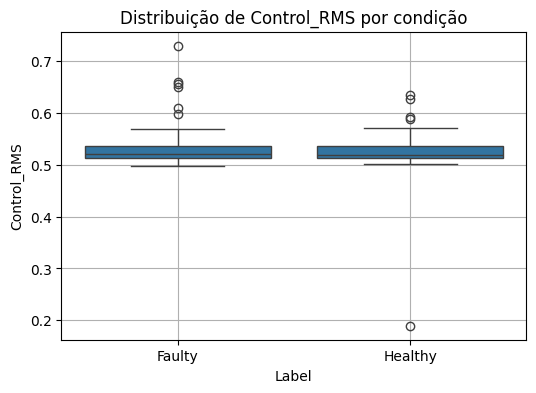

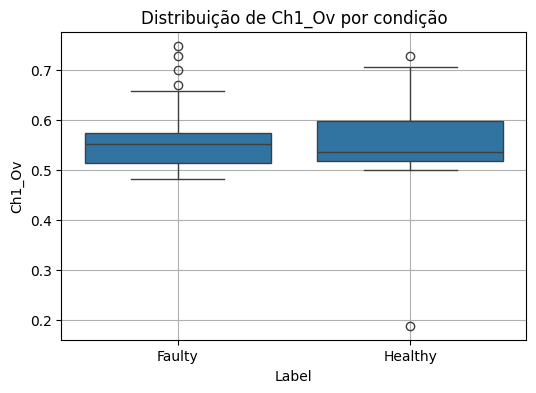

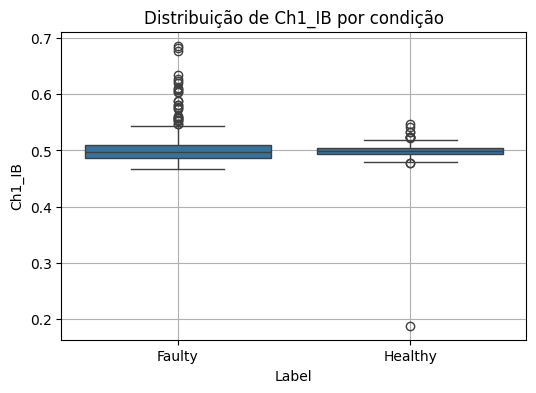

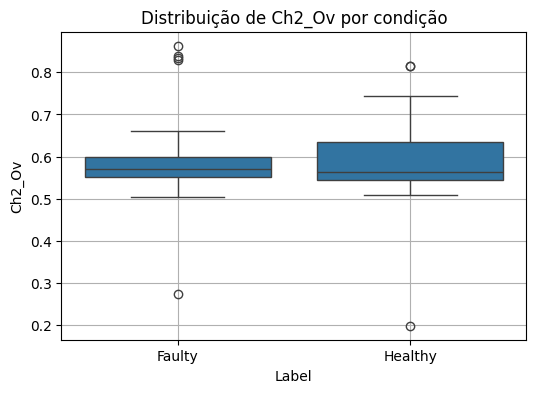

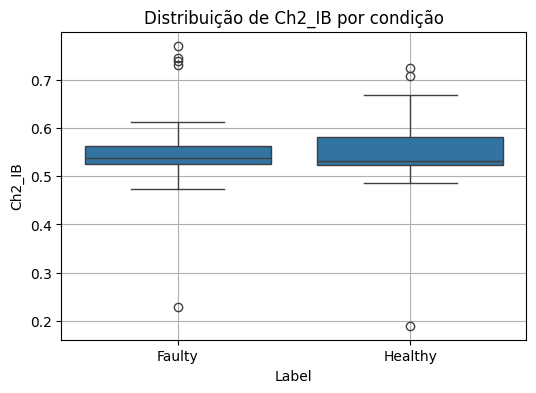

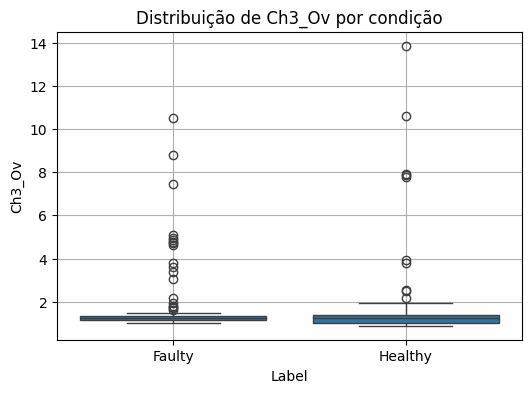

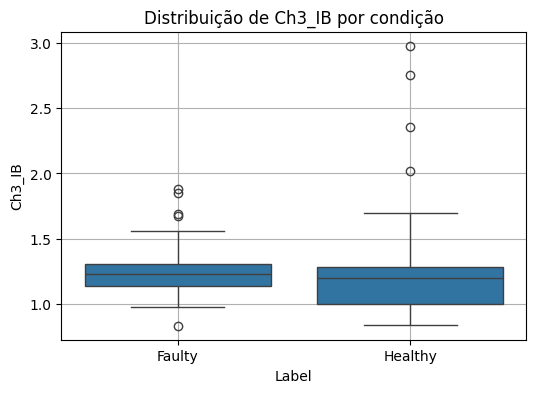

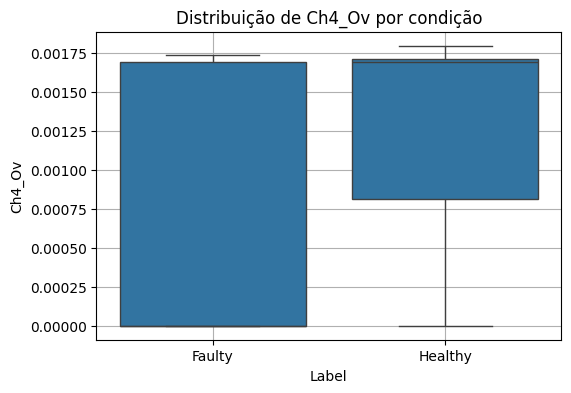

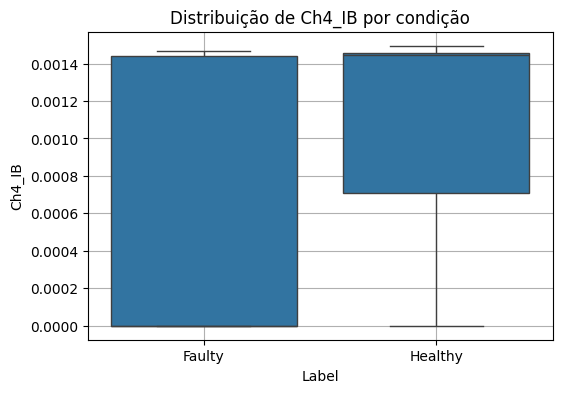

In [ ]:
cols_plot = [
    "Demand_RMS",
    "Control_RMS",
    "Ch1_Ov",
    "Ch1_IB",
    "Ch2_Ov",
    "Ch2_IB",
    "Ch3_Ov",
    "Ch3_IB",
    "Ch4_Ov",
    "Ch4_IB"
]

for col in cols_plot:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=df,
        x="Label",
        y=col
    )

    plt.title(f"Distribuição de {col} por condição")
    plt.grid(True)

    plt.show()

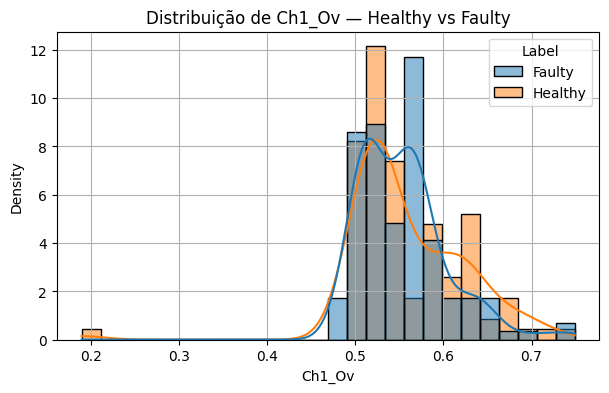

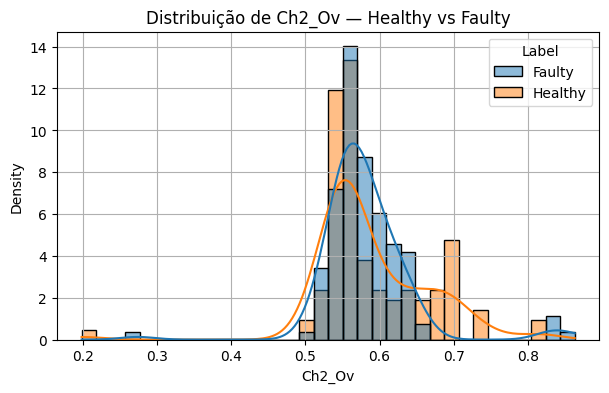

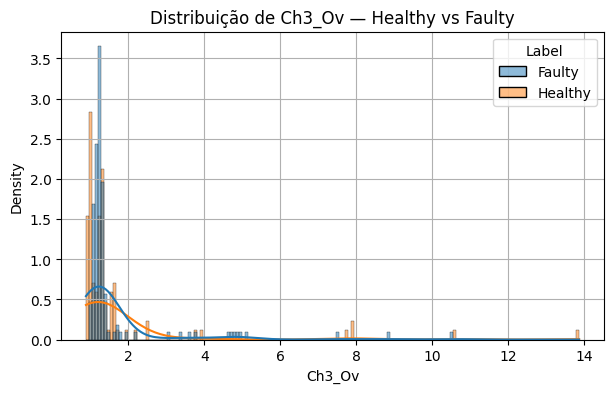

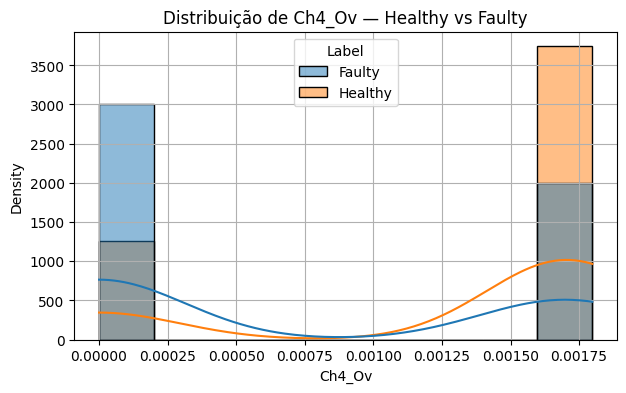

In [ ]:
cols_plot = [
    "Ch1_Ov",
    "Ch2_Ov",
    "Ch3_Ov",
    "Ch4_Ov"
]

for col in cols_plot:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        hue="Label",
        kde=True,
        stat="density",
        common_norm=False
    )

    plt.title(f"Distribuição de {col} — Healthy vs Faulty")

    plt.grid(True)

    plt.show()

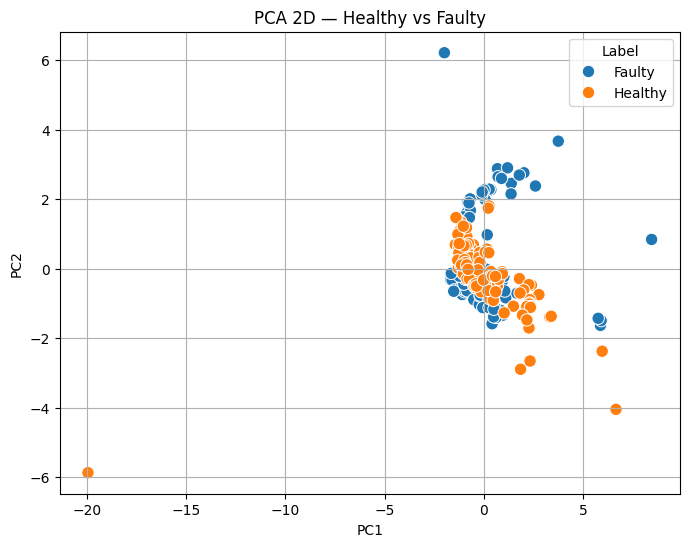

In [ ]:
features_pca = [
    "Demand_RMS",
    "Control_RMS",
    "Ch1_Ov",
    "Ch1_IB",
    "Ch2_Ov",
    "Ch2_IB",
    "Ch3_IB",
]

X = df[features_pca]

# normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# dataframe auxiliar
df_pca = df.copy()

df_pca["PC1"] = X_pca[:,0]
df_pca["PC2"] = X_pca[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Label",
    s=80
)

plt.title("PCA 2D — Healthy vs Faulty")

plt.grid(True)

plt.show()

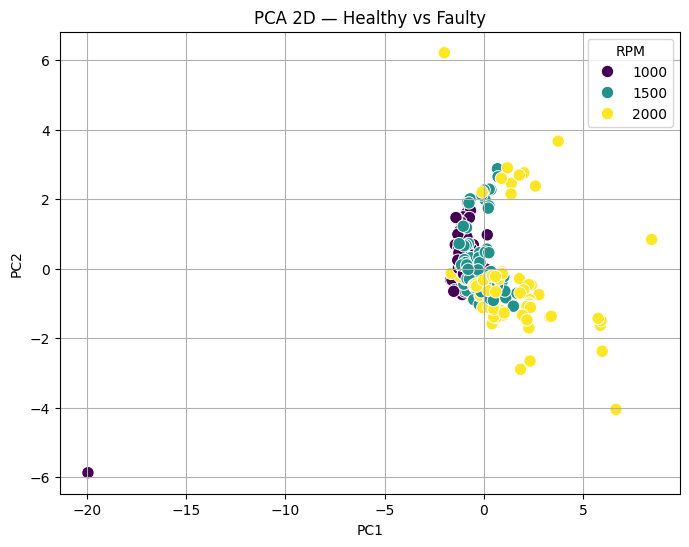

In [ ]:
features_pca = [
    "Demand_RMS",
    "Control_RMS",
    "Ch1_Ov",
    "Ch1_IB",
    "Ch2_Ov",
    "Ch2_IB",
    "Ch3_IB",
]

X = df[features_pca]

# normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# dataframe auxiliar
df_pca = df.copy()

df_pca["PC1"] = X_pca[:,0]
df_pca["PC2"] = X_pca[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="RPM",
    palette="viridis",
    s=80
)

plt.title("PCA 2D — Healthy vs Faulty")

plt.grid(True)

plt.show()

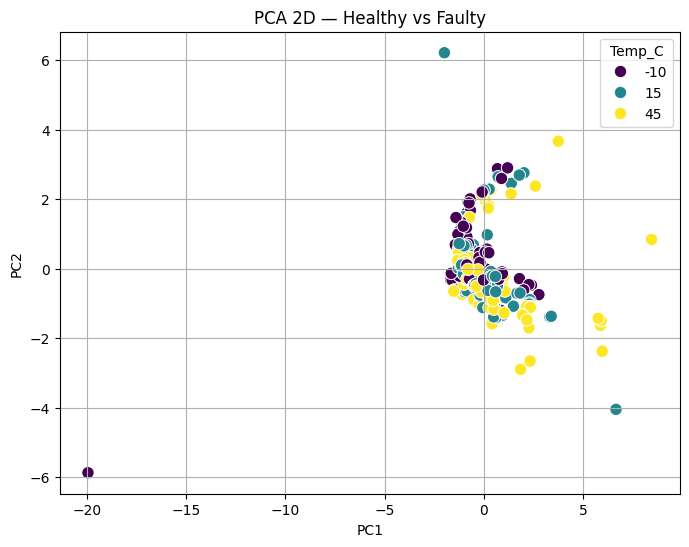

In [ ]:
features_pca = [
    "Demand_RMS",
    "Control_RMS",
    "Ch1_Ov",
    "Ch1_IB",
    "Ch2_Ov",
    "Ch2_IB",
    "Ch3_IB",
]

X = df[features_pca]

# normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# dataframe auxiliar
df_pca = df.copy()

df_pca["PC1"] = X_pca[:,0]
df_pca["PC2"] = X_pca[:,1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="Temp_C",
    palette="viridis",
    s=80
)

plt.title("PCA 2D — Healthy vs Faulty")

plt.grid(True)

plt.show()

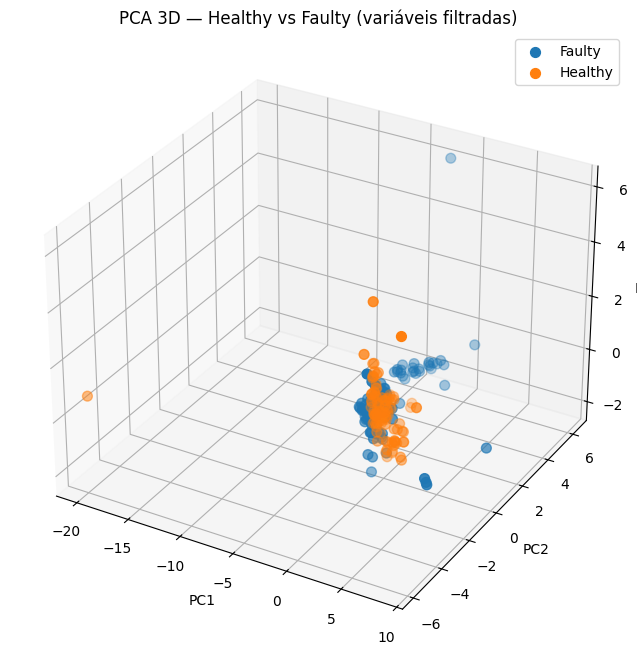

In [ ]:
features_pca_filtered = [
    "Demand_RMS",
    "Control_RMS",
    "Ch1_Ov",
    "Ch1_IB",
    "Ch2_Ov",
    "Ch2_IB",
    "Ch3_IB"
]

X_filtered = df[features_pca_filtered]

scaler = StandardScaler()
X_filtered_scaled = scaler.fit_transform(X_filtered)

pca3_filtered = PCA(n_components=3)
X_pca3_filtered = pca3_filtered.fit_transform(X_filtered_scaled)

df_pca3_filtered = df.copy()
df_pca3_filtered["PC1"] = X_pca3_filtered[:, 0]
df_pca3_filtered["PC2"] = X_pca3_filtered[:, 1]
df_pca3_filtered["PC3"] = X_pca3_filtered[:, 2]


fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

for label in df_pca3_filtered["Label"].unique():
    subset = df_pca3_filtered[df_pca3_filtered["Label"] == label]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        subset["PC3"],
        label=label,
        s=50
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("PCA 3D — Healthy vs Faulty (variáveis filtradas)")
plt.legend()
plt.show()


In [ ]:
# =========================================================
# 2. Definição das features e target
# =========================================================

features = [
    "RPM",
    "Humidity_%",
    "Temp_C",
    "Demand_RMS",
    "Control_RMS",
    "Ch1_Ov",
    "Ch1_IB",
    "Ch2_Ov",
    "Ch2_IB",
    "Ch3_Ov",
    "Ch3_IB",
    "Ch4_Ov",
    "Ch4_IB"
]

X = df[features]
y = df["Label"]

# Converter Healthy/Faulty para 0/1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Mapeamento das classes:")
for i, label in enumerate(label_encoder.classes_):
    print(i, "=", label)

Mapeamento das classes:
0 = Faulty
1 = Healthy


In [ ]:
# =========================================================
# 3. Split treino/teste
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

print("Tamanho treino:", X_train.shape)
print("Tamanho teste:", X_test.shape)

Tamanho treino: (181, 13)
Tamanho teste: (61, 13)


In [ ]:
# =========================================================
# 4. Modelo default — Random Forest
# =========================================================

rf_default = RandomForestClassifier(
    random_state=42
)

rf_default.fit(X_train, y_train)

y_pred_rf = rf_default.predict(X_test)

print("=== Random Forest Default ===")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=label_encoder.classes_,
    digits=4
))

=== Random Forest Default ===
              precision    recall  f1-score   support

      Faulty     0.8649    0.9412    0.9014        34
     Healthy     0.9167    0.8148    0.8627        27

    accuracy                         0.8852        61
   macro avg     0.8908    0.8780    0.8821        61
weighted avg     0.8878    0.8852    0.8843        61



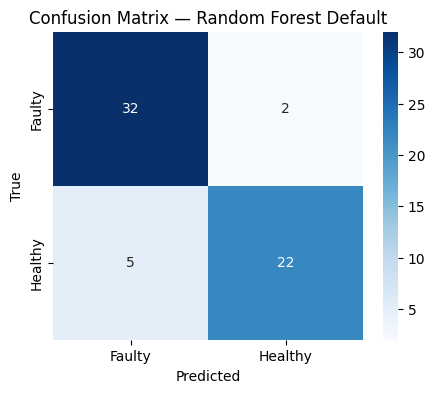

In [ ]:
# =========================================================
# 5. Matriz de confusão — Random Forest
# =========================================================

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Random Forest Default")
plt.show()

In [ ]:
# =========================================================
# 7. Modelo default — XGBoost
# =========================================================

from xgboost import XGBClassifier

xgb_default = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_default.fit(X_train, y_train)

y_pred_xgb = xgb_default.predict(X_test)

print("=== XGBoost Default ===")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=label_encoder.classes_,
    digits=4
))

=== XGBoost Default ===
              precision    recall  f1-score   support

      Faulty     0.8824    0.8824    0.8824        34
     Healthy     0.8519    0.8519    0.8519        27

    accuracy                         0.8689        61
   macro avg     0.8671    0.8671    0.8671        61
weighted avg     0.8689    0.8689    0.8689        61



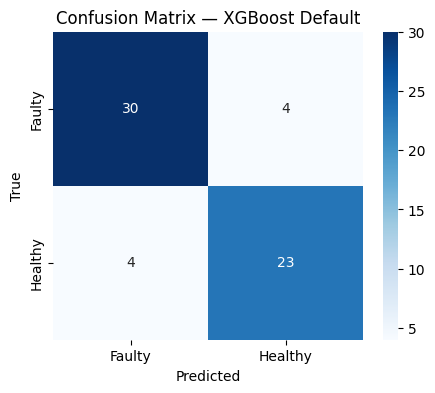

In [ ]:
# =========================================================
# 8. Matriz de confusão — XGBoost
# =========================================================

cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — XGBoost Default")
plt.show()